<a href="https://colab.research.google.com/github/luciferdummy/AIML_Activity/blob/main/aiml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Science Salary Prediction

This notebook will guide you through the process of predicting data science salaries using a Linear Regression model. We'll cover data loading, exploration, preprocessing, model training, and evaluation.

### 1. Initial Setup and Data Loading

First, we'll import necessary libraries, load the `ds_salaries.csv` dataset, and perform initial data cleaning by dropping duplicate rows.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from google.colab import files

try:
    df = pd.read_csv('/content/ds_salaries.csv')
except FileNotFoundError:
    print("Please upload 'ds_salaries.csv':")
    uploaded = files.upload()
    df = pd.read_csv(next(iter(uploaded)))

df.drop_duplicates(inplace=True)
display(df.head())

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [ ]:
print('DataFrame Info:')
df.info()
print('\nDataFrame Description:')
display(df.describe())

print('\nUnique values for categorical columns:')
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    if df[col].nunique() < 20: # Display only columns with fewer than 20 unique values for brevity
        print(f"{col}: {df[col].unique()}")

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB

DataFrame Description:


,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000



Unique values for categorical columns:
experience_level: ['MI' 'SE' 'EN' 'EX']
employment_type: ['FT' 'CT' 'PT' 'FL']
salary_currency: ['EUR' 'USD' 'GBP' 'HUF' 'INR' 'JPY' 'CNY' 'MXN' 'CAD' 'DKK' 'PLN' 'SGD'
 'CLP' 'BRL' 'TRY' 'AUD' 'CHF']
company_size: ['L' 'S' 'M']


### 3. Exploratory Data Analysis (EDA)

We will visualize the distribution of salaries and explore how salary varies with experience level. These plots use the original `df` before extensive transformations.

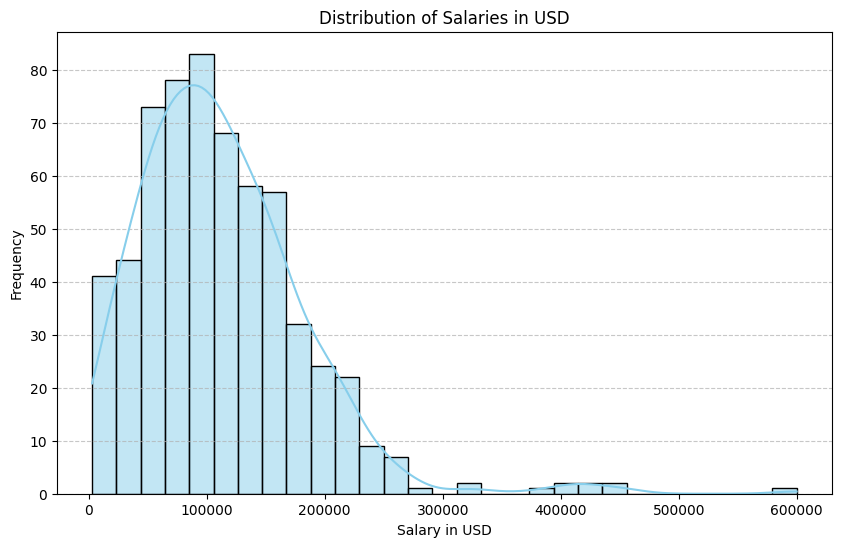

/tmp/ipykernel_539/685963185.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='experience_level', y='salary_in_usd', data=df, palette='viridis')


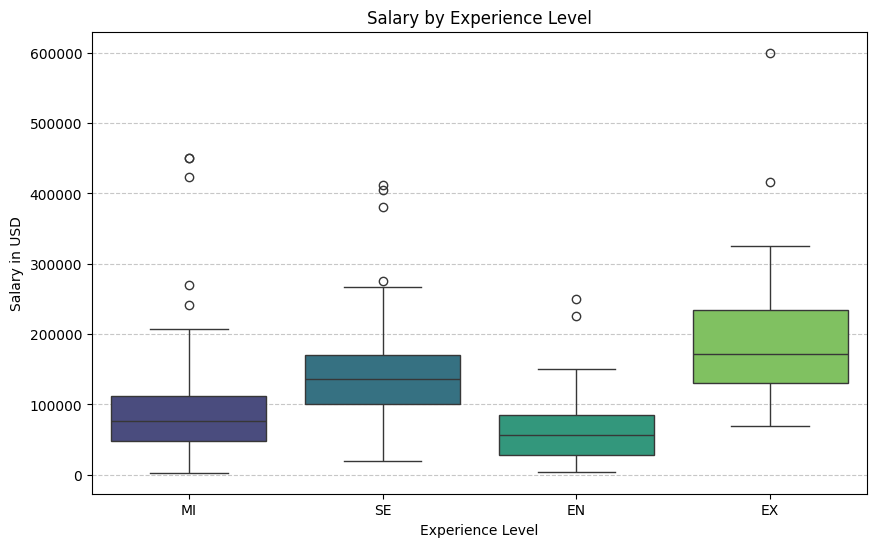

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_in_usd'], kde=True, color='skyblue')
plt.title('Distribution of Salaries in USD')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df, palette='viridis')
plt.title('Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary in USD')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4. Data Preprocessing

Next, we'll prepare the data for our machine learning model. This involves handling categorical features by grouping less frequent categories into 'Other' and then creating dummy variables. We will also drop the original `salary` and `salary_currency` columns as `salary_in_usd` is our target variable.

In [ ]:
categorical_features = ['experience_level', 'employment_type', 'job_title', 'employee_residence', 'company_location', 'company_size']

# Group less frequent categories into 'Other' for selected columns to reduce dimensionality
for col in ['job_title', 'employee_residence', 'company_location']:
    top_n = df[col].value_counts().nlargest(10).index
    df[col] = np.where(df[col].isin(top_n), df[col], 'Other')

# Drop original salary and salary_currency columns
df = df.drop(['salary', 'salary_currency'], axis=1, errors='ignore')

# Create dummy variables for all specified categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)
display(df_encoded.head())

,Unnamed: 0,work_year,salary_in_usd,remote_ratio,experience_level_EX,experience_level_MI,experience_level_SE,employment_type_FL,employment_type_FT,employment_type_PT,...,company_location_FR,company_location_GB,company_location_GR,company_location_IN,company_location_JP,company_location_NL,company_location_Other,company_location_US,company_size_M,company_size_S
0,0,2020,79833,0,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,1,2020,260000,0,False,False,True,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,2,2020,109024,50,False,False,True,False,True,False,...,False,True,False,False,False,False,False,False,True,False
3,3,2020,20000,0,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
4,4,2020,150000,50,False,False,True,False,True,False,...,False,False,False,False,False,False,False,True,False,False


### 5. Feature Scaling and Data Splitting

We'll define our features (X) and target (y), split the data into training and testing sets, and scale numerical features to ensure they contribute equally to the model.

In [ ]:
X = df_encoded.drop(['salary_in_usd'], axis=1, errors='ignore')
y = df_encoded['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numerical features to scale (excluding dummy variables)
numerical_features = ['work_year', 'remote_ratio']

# Initialize StandardScaler and apply to numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (485, 41)
X_test shape: (122, 41)
y_train shape: (485,)
y_test shape: (122,)


### 6. Model Training

Now, we'll train a Linear Regression model using our prepared training data.

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### 7. Model Evaluation

Finally, we'll evaluate the model's performance on the test set and visualize the actual vs. predicted salaries to assess its accuracy.

Model R2 Score: 0.5225


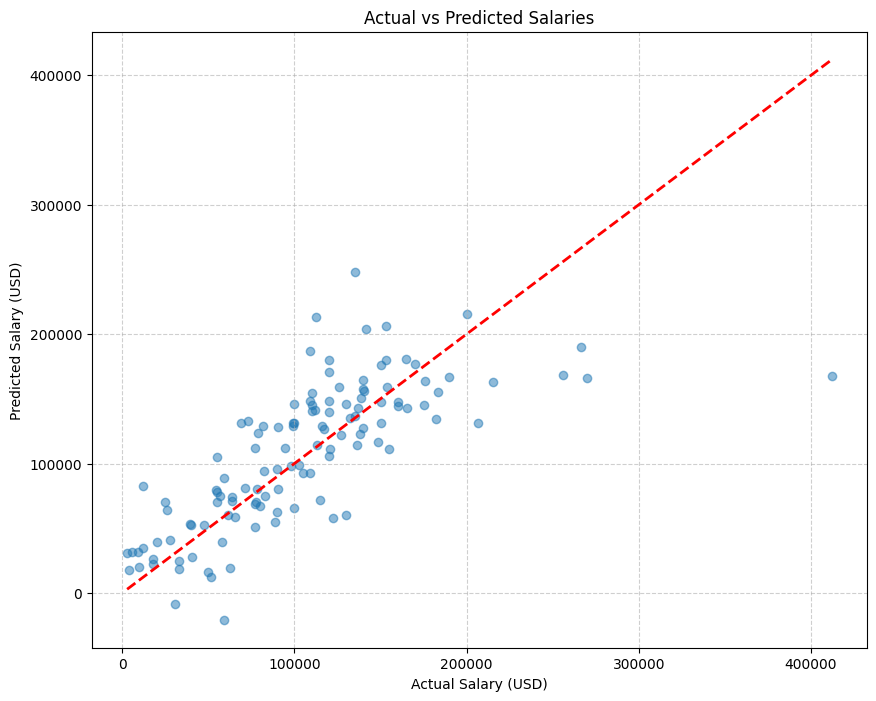

In [ ]:
y_pred = model.predict(X_test)

print(f"Model R2 Score: {r2_score(y_test, y_pred):.4f}")

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Salary (USD)')
plt.ylabel('Predicted Salary (USD)')
plt.title('Actual vs Predicted Salaries')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from google.colab import files

try:
    df = pd.read_csv('/content/ds_salaries.csv')
except FileNotFoundError:
    print("Please upload 'ds_salaries.csv':")
    uploaded = files.upload()
    df = pd.read_csv(next(iter(uploaded)))

df.drop_duplicates(inplace=True)
display(df.head())

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


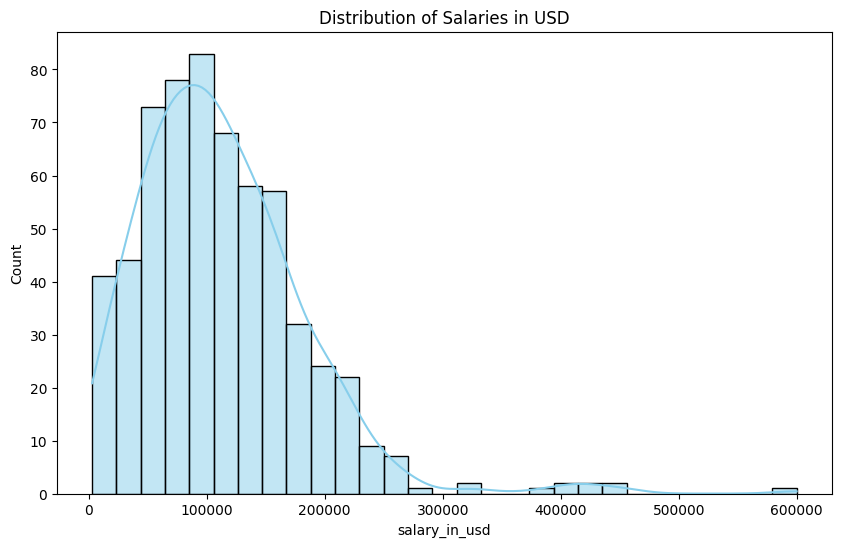

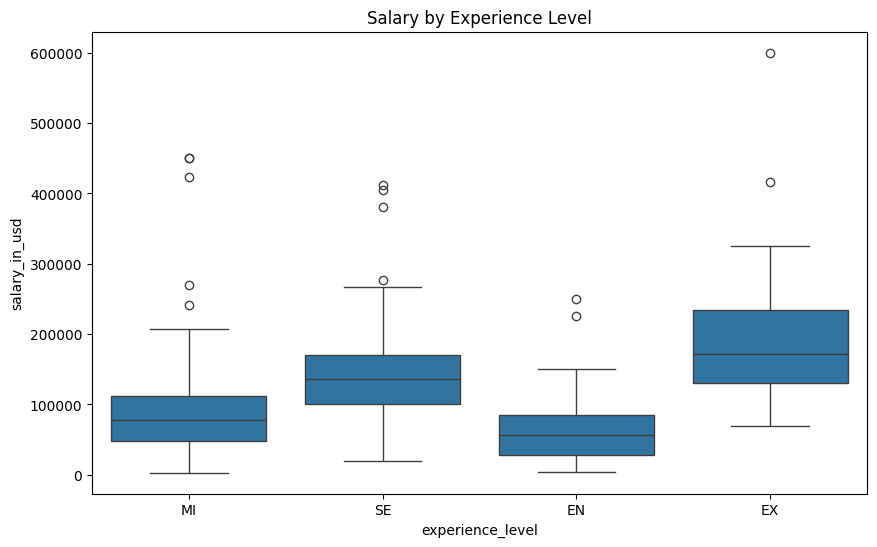

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_in_usd'], kde=True, color='skyblue')
plt.title('Distribution of Salaries in USD')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df)
plt.title('Salary by Experience Level')
plt.show()

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Model R2 Score: {r2_score(y_test, y_pred):.4f}")

Model R2 Score: 0.5225


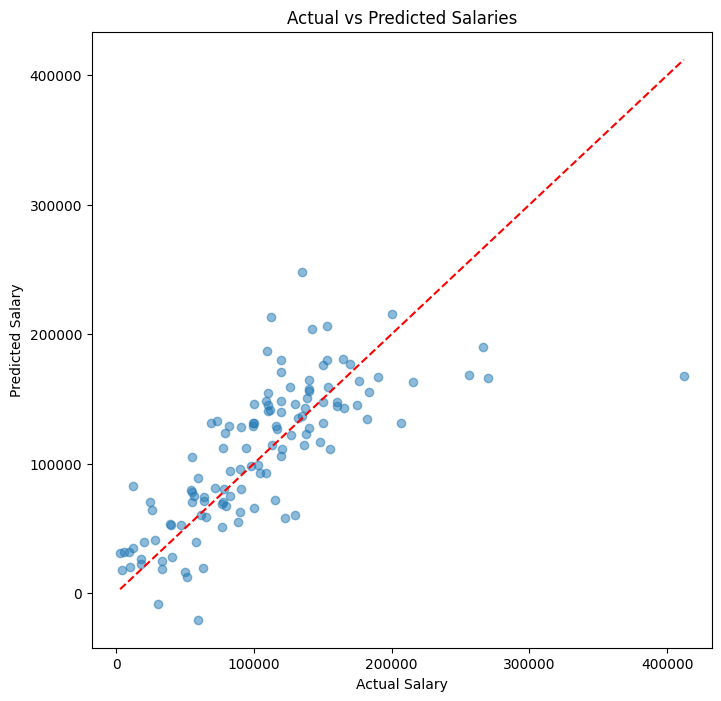

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salaries')
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv('/content/ds_salaries.csv')
display(df.head())

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [ ]:
df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [ ]:
display(df.describe())

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [ ]:
categorical_features = ['experience_level', 'employment_type', 'job_title', 'employee_residence', 'company_location', 'company_size']
for col in ['job_title', 'employee_residence', 'company_location']:
    top_n = df[col].value_counts().nlargest(10).index
    df[col] = np.where(df[col].isin(top_n), df[col], 'Other')

df = df.drop(['salary', 'salary_currency'], axis=1, errors='ignore')
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

In [ ]:
X = df_encoded.drop(['salary_in_usd'], axis=1, errors='ignore')
y = df_encoded['salary_in_usd']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numerical_features = ['work_year', 'remote_ratio']
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    if df[col].nunique() < 20:
        print(f"{col}: {df[col].unique()}")

experience_level: ['MI' 'SE' 'EN' 'EX']
employment_type: ['FT' 'CT' 'PT' 'FL']
job_title: ['Data Scientist' 'Machine Learning Scientist' 'Big Data Engineer' 'Other'
 'Machine Learning Engineer' 'Data Analyst' 'Data Engineer'
 'Director of Data Science' 'Research Scientist' 'Data Science Manager'
 'Data Architect']
employee_residence: ['DE' 'JP' 'GB' 'Other' 'US' 'FR' 'IN' 'PT' 'GR' 'CA' 'ES']
company_location: ['DE' 'JP' 'GB' 'Other' 'US' 'FR' 'IN' 'GR' 'NL' 'CA' 'ES']
company_size: ['L' 'S' 'M']


In [ ]:
df = df.drop(['salary', 'salary_currency'], axis=1)